### 1-1. 전처리 및 차이검정 

In [ ]:
# ======================================
# ✅ 1-1번 코드(수정): 전처리 + sat(연속)까지만 생성, 차이검정 
# - sat_group(이진화)는 만들지 않음 (반드시 split 이후 train median으로 생성)
# ======================================

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# 1. 데이터 로드
# ============================================================
df = pd.read_csv('univ355.csv')

# ============================================================
# 2. 대량 결측치 또는 의미 부족 변수 제거
# ============================================================
drop_missing_cols = [
    'why_not_rechoice', 'future_job_desc', 'income_class', 'income_contest',
    'income_perf', 'income_broadcast', 'income_studio', 'income_creator',
    'income_choreo', 'info_dept', 'info_career_center', 'info_online',
    'info_family', 'info_friends', 'info_academy', 'info_self',
    'help_financial', 'help_resume', 'help_career', 'help_social',
    'help_no', 'non_stay_reason', 'total_univ', 'id'
]
df = df.drop(columns=drop_missing_cols, errors='ignore')

# ============================================================
# 3. 지역 관련 중복 변수 제거
# ============================================================
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')

# ============================================================
# 4. 오타 및 잘못된 범주값 정정
# ============================================================
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})

# ============================================================
# 5. 범주형 변수 매핑 및 원-핫 인코딩
# ============================================================

# 5-1) 무용경력 구간 변환(ordinal coding)
midpoint_map = {'less2': 1, '2to4': 2, '4to7': 3, '7to10': 4, 'over10': 5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)


# ============================================================
# [추가] t-test 및 ANOVA 분석 (원-핫 인코딩 전에 수행해야 함!)
# ============================================================
import scipy.stats as stats

# 1. 분석 대상 변수 정의 (표에 근거)
target_vars = [
    # 이진형 변수들
    'gender', 'rechoice_major', 'move_for_univ', 'has_future_job', 
    'has_income', 'has_major_income', 'burnout', 'career_course', 
    'career_mentoring', 'job_test', 'job_prep', 'field_practice', 
    'abroad_practice', 'job_info', 'job_fair', 'exp_solo_comp', 
    'exp_group_comp', 'exp_concours', 'exp_perf', 'exp_video', 'exp_broadcast',
    
    # 다범주형 변수들 (ANOVA 대상)
    'univ_factor', 'major_factor', 'job_region', 'weight_control', 
    'birth_area', 'housing_type', 'enter_type', 'major_detail', 
    'univ_name', 'univ_area'
]

# 2. sat(연속형) 지표 미리 생성 (분석을 위해 순서를 앞당김)
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
df['sat'] = df[sat_cols].mean(axis=1)

analysis_results = []

for var in target_vars:
    if var not in df.columns:
        continue
    
    # 결측치 제거 후 해당 변수와 sat만 추출
    temp_df = df[[var, 'sat']].dropna()
    unique_vals = temp_df[var].unique()
    num_groups = len(unique_vals)
    
    # 집단별 데이터 리스트 생성
    groups = [temp_df[temp_df[var] == val]['sat'].values for val in unique_vals]
    
    # 집단이 2개면 t-test
    if num_groups == 2:
        t_stat, p_val = stats.ttest_ind(groups[0], groups[1], equal_var=False)
        analysis_results.append({
            'Variable': var, 'Method': 't-test', 'Groups': num_groups,
            'Statistic': round(t_stat, 3), 'p-value': round(p_val, 4)
        })
    # 집단이 3개 이상이면 ANOVA
    elif num_groups >= 3:
        f_stat, p_val = stats.f_oneway(*groups)
        analysis_results.append({
            'Variable': var, 'Method': 'ANOVA', 'Groups': num_groups,
            'Statistic': round(f_stat, 3), 'p-value': round(p_val, 4)
        })

# 결과 출력
result_df = pd.DataFrame(analysis_results)
significant_vars = result_df[result_df['p-value'] < 0.05]

print("\n📊 [전체 분석 결과 - 인코딩 전]")
print(result_df)
print("\n✨ [통계적으로 유의미한 변수 (p < 0.05)]")
print(significant_vars)

# ============================================================
# 이후 기존 코드의 5-2) 원-핫 인코딩(pd.get_dummies) 단계를 실행하세요.
# ============================================================

# 5-2) 범주형 변수 원-핫 인코딩 (drop_first=True)
columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type',
    'major_detail', 'univ_name', 'univ_area'
]
df = pd.get_dummies(
    df,
    columns=columns_to_encode,
    drop_first=True,
    dtype=float
)

# ============================================================
# 6. 사전 정의된 분석 제외 변수 제거
# ============================================================
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')

# ============================================================
# 7. 다중공선성 우려 변수 사전 제거
# ============================================================
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat', 'peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')

# ============================================================
# 8. sat(연속) 지표 생성 (✅ 여기까지만!)
# ============================================================
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
for c in sat_cols:
    if c not in df.columns:
        raise RuntimeError(f"sat 구성 문항 컬럼이 없습니다: {c}")

df['sat'] = df[sat_cols].mean(axis=1)

# ============================================================
# 9. 설명용 출력
# ============================================================
print("✅ 전처리 완료 (sat_group은 split 이후 train median으로 생성합니다)")
print("✅ 최종 데이터셋 컬럼 수:", df.shape[1])
print(df[['sat']].head())



📊 [전체 분석 결과 - 인코딩 전]
            Variable  Method  Groups  Statistic  p-value
0             gender  t-test       2     -0.519   0.6047
1     rechoice_major  t-test       2     -4.335   0.0000
2      move_for_univ  t-test       2      0.726   0.4684
3     has_future_job  t-test       2     -1.124   0.2619
4         has_income  t-test       2     -2.623   0.0094
5   has_major_income  t-test       2      0.473   0.6366
6            burnout  t-test       2     -1.584   0.1144
7      career_course  t-test       2     -3.095   0.0022
8   career_mentoring  t-test       2     -1.559   0.1199
9           job_test  t-test       2      0.111   0.9117
10          job_prep  t-test       2     -2.921   0.0040
11    field_practice  t-test       2      2.826   0.0050
12   abroad_practice  t-test       2     -2.046   0.0439
13          job_info  t-test       2     -2.722   0.0072
14          job_fair  t-test       2     -1.546   0.1289
15     exp_solo_comp  t-test       2      3.206   0.0015
16    exp

### 1_2. 사후검증

In [ ]:
# 1_2 차이검정 사후검증 
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 데이터 다시 로드 (원본 보존을 위해)
df_analysis = pd.read_csv('univ355.csv')

# 2. 분석에 필요한 sat 지표 생성
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
df_analysis['sat'] = df_analysis[sat_cols].mean(axis=1)

# 3. 분석 대상 변수 정의
t_test_vars = ['rechoice_major', 'exp_solo_comp', 'career_course', 'job_prep', 
               'field_practice', 'job_info', 'exp_concours', 'has_income', 'abroad_practice']

anova_vars = ['univ_area', 'univ_name', 'univ_factor', 'major_detail']

print("="*60)
print("📊 [t-test 변수] 집단별 만족도(Sat) 평균 및 표준편차")
print("="*60)

for var in t_test_vars:
    if var in df_analysis.columns:
        # 결측치 제외 후 집단별 통계
        res = df_analysis.groupby(var)['sat'].agg(['count', 'mean', 'std']).round(3)
        print(f"\n🔹 변수명: {var}")
        print(res)

print("\n" + "="*60)
print("✨ [ANOVA 변수] 사후검증(Tukey HSD) 및 부등호 관계")
print("="*60)

for var in anova_vars:
    if var in df_analysis.columns:
        temp = df_analysis[[var, 'sat']].dropna()
        
        # 1. 집단별 평균 순위 출력
        means = temp.groupby(var)['sat'].mean().sort_values(ascending=False).round(3)
        print(f"\n▶ 변수명: {var} (평균 높은 순: {list(means.index)})")
        print(means)
        
        # 2. 사후검증 실행
        if temp[var].nunique() > 1:
            posthoc = pairwise_tukeyhsd(temp['sat'], temp[var], alpha=0.05)
            ph_df = pd.DataFrame(posthoc.summary().data[1:], columns=posthoc.summary().data[0])
            significant_pairs = ph_df[ph_df['reject'] == True]
            
            if not significant_pairs.empty:
                print(f"   [통계적으로 유의미한 차이 쌍]:")
                for idx, row in significant_pairs.iterrows():
                    # 차이의 방향 확인
                    higher = row['group2'] if row['meandiff'] > 0 else row['group1']
                    lower = row['group1'] if row['meandiff'] > 0 else row['group2']
                    print(f"    - {higher} > {lower} (p={row['p-adj']:.4f})")
            else:
                print("   (전체 차이는 유의하나, 개별 쌍 간의 대비는 뚜렷하지 않음)")

📊 [t-test 변수] 집단별 만족도(Sat) 평균 및 표준편차

🔹 변수명: rechoice_major
                count   mean    std
rechoice_major                     
0                  61  3.361  1.072
1                 294  3.996  0.878

🔹 변수명: exp_solo_comp
               count   mean    std
exp_solo_comp                     
0                143  3.692  0.951
1                212  4.018  0.918

🔹 변수명: career_course
               count   mean    std
career_course                     
0                220  3.769  0.966
1                135  4.078  0.876

🔹 변수명: job_prep
          count   mean    std
job_prep                     
0           262  3.803  0.953
1            93  4.121  0.881

🔹 변수명: field_practice
                count   mean    std
field_practice                     
0                 158  3.728  1.001
1                 197  4.014  0.877

🔹 변수명: job_info
          count   mean    std
job_info                     
0           266  3.811  0.952
1            89  4.112  0.887

🔹 변수명: exp_concours
          

### 2-1.변수선택(저만족(1) 변별력 기준)

In [4]:
# ======================================
# ✅ 2번 코드(최종본): 변수선택을 6:2:2 파이프라인 안으로 완전 통합
# - 목적: "변수선택 단계에서도 test를 절대 사용하지 않기"
# - 라벨 기준: 저만족=1, 고만족=0
#
# [반복(rep)마다]
# 1) split: (train_val/test)=80/20 → (train/val)=75/25  => 60/20/20
# 2) thr: median(sat_train) 로만 결정
# 3) y_train/y_val 생성(저만족=1, 고만족=0)
# 4) 변수선택은 오직 Train(60%)에서만 수행
# 5) 각 변수선택 결과로 LR(고정) 모델을 학습하여 Val(20%)에서만 성능 평가
# 6) rep마다 "Val 성능 기준"으로 1등 변수선택법을 기록
#
# 출력:
# - rep별 선택된 변수셋(각 방법별)
# - rep별 Val 성능(각 방법별)
# - rep별 Val 1등 선택 기록(best_pick_by_rep)
# - 방법별: (a) Val 평균±SD (b) rep 내 1등 빈도 (c) 선택 안정성(Jaccard/교집합/빈도)
# ======================================

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 필수 체크: df, sat
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")

# -------------------------
# 1) X, sat 구성 (누수 방지: sat 및 sat 구성문항 제거)
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# -------------------------
# 2) 유틸: 평균 pairwise Jaccard (선택 안정성)
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan
    vals = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            a, b = list_of_sets[i], list_of_sets[j]
            inter = len(a & b)
            union = len(a | b)
            vals.append(inter / union if union > 0 else 0.0)
    return float(np.mean(vals)) if vals else np.nan

# -------------------------
# 3) 유틸: class=1 지표
#   - 여기서 class 1 = 저만족
#   - recall_1    = TP / (TP + FN)
#   - precision_1 = TP / (TP + FP)
#   - f1_1
# -------------------------
def class1_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (2 * precision_1 * recall_1 / (precision_1 + recall_1)) if (precision_1 + recall_1) > 0 else np.nan
    return recall_1, precision_1, f1_1

def get_score(fitted_model, X):
    # ROC-AUC용 score (positive class=1 = 저만족)
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 4) 변수선택 함수들 (Train에서만 사용)
# -------------------------
def enet_select(X_tr, y_tr, rs):
    """
    ElasticNet 임베디드 방식:
    - StandardScaler + LogisticRegressionCV(elasticnet)
    - coef != 0 인 변수 선택
    - y=1은 저만족
    """
    selector = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=20,
            cv=5,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5],
            max_iter=10000,
            n_jobs=-1,
            random_state=rs
        ))
    ])
    selector.fit(X_tr, y_tr)
    coef = selector.named_steps["clf"].coef_.ravel()
    sel_cols = list(X_tr.columns[coef != 0])
    return sel_cols

def rfecv_select(method, X_tr, y_tr, rs):
    """
    RFECV 래퍼 방식:
    - method별 base estimator
    - scoring='f1' (positive class=1 = 저만족)
    """
    if method == "LR":
        base = LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs)
        selector = Pipeline([
            ("scaler", StandardScaler()),
            ("rfecv", RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1))
        ])
        selector.fit(X_tr, y_tr)
        support = selector.named_steps["rfecv"].support_
        return list(X_tr.columns[support])

    if method == "DT":
        base = DecisionTreeClassifier(random_state=rs)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "RF":
        base = RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "XGB":
        base = XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    raise ValueError("method는 'LR','DT','RF','XGB' 중 하나여야 합니다.")

# -------------------------
# 5) "변수선택 결과"를 Val에서 평가하는 모델(고정)
#    - 모델은 LR로 고정
#    - 해석 대상: 저만족(1) 분류 성능
# -------------------------
def fit_and_eval_on_val(X_tr, y_tr, X_va, y_va, rs):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    fitted = model.fit(X_tr, y_tr)
    y_pred = fitted.predict(X_va)

    recall_1, precision_1, f1_1 = class1_metrics(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_va, y_pred)
    acc = accuracy_score(y_va, y_pred)

    score = get_score(fitted, X_va)
    try:
        auc = roc_auc_score(y_va, score) if (score is not None and len(np.unique(y_va)) == 2) else np.nan
    except Exception:
        auc = np.nan

    return {
        "Val_recall_1": recall_1,
        "Val_precision_1": precision_1,
        "Val_f1_1": f1_1,
        "Val_f1_macro": f1_macro,
        "Val_balanced_acc": bal_acc,
        "Val_accuracy": acc,
        "Val_roc_auc": auc
    }

# -------------------------
# 6) ✅ Repeated Hold-out (6:2:2) 30회
#    - test는 이 코드에서 "절대 사용하지 않음"
# -------------------------
N_REP = 30
methods = ["ElasticNet", "RFECV(LR)", "RFECV(DT)", "RFECV(RF)", "RFECV(XGB)"]

# rep별 선택 변수셋 저장(안정성 분석용)
rep_selected_sets = {m: [] for m in methods}

# rep별 Val 성능 저장
rep_val_perf = {m: [] for m in methods}

# rep별 1등(Val 기준) 기록
best_pick_by_rep = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # -------------------------
    # (1) 80/20 split: train_val / test  (✅ test 분리)
    # -------------------------
    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full,
        test_size=0.2,
        random_state=rs
    )

    # -------------------------
    # (2) 75/25 split: train / val  (✅ 최종 0.6 / 0.2 / 0.2)
    # -------------------------
    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val,
        test_size=0.25,
        random_state=rs
    )

    # -------------------------
    # (3) ✅ train median으로만 thr 결정 → y 생성
    #     저만족=1, 고만족=0
    # -------------------------
    thr = float(sat_train.median())
    y_train = (sat_train < thr).astype(int)
    y_val   = (sat_val   < thr).astype(int)

    # -------------------------
    # (4) 변수선택: Train에서만
    # -------------------------
    cols_enet = enet_select(X_train, y_train, rs)
    rep_selected_sets["ElasticNet"].append(set(cols_enet))

    cols_rlr  = rfecv_select("LR",  X_train, y_train, rs)
    cols_rdt  = rfecv_select("DT",  X_train, y_train, rs)
    cols_rrf  = rfecv_select("RF",  X_train, y_train, rs)
    cols_rxgb = rfecv_select("XGB", X_train, y_train, rs)

    rep_selected_sets["RFECV(LR)"].append(set(cols_rlr))
    rep_selected_sets["RFECV(DT)"].append(set(cols_rdt))
    rep_selected_sets["RFECV(RF)"].append(set(cols_rrf))
    rep_selected_sets["RFECV(XGB)"].append(set(cols_rxgb))

    # -------------------------
    # (5) Val 성능 평가: 선택된 변수셋 품질(모델은 LR로 고정)
    # -------------------------
    def safe_eval(cols):
        metric_cols = [
            "Val_recall_1", "Val_precision_1", "Val_f1_1",
            "Val_f1_macro", "Val_balanced_acc", "Val_accuracy", "Val_roc_auc"
        ]
        if cols is None or len(cols) == 0:
            out = {k: np.nan for k in metric_cols}
            out["n_features"] = 0
            return out

        metrics = fit_and_eval_on_val(
            X_train[cols], y_train,
            X_val[cols], y_val,
            rs
        )
        metrics["n_features"] = len(cols)
        return metrics

    perf_enet = safe_eval(cols_enet)
    perf_rlr  = safe_eval(cols_rlr)
    perf_rdt  = safe_eval(cols_rdt)
    perf_rrf  = safe_eval(cols_rrf)
    perf_rxgb = safe_eval(cols_rxgb)

    rep_val_perf["ElasticNet"].append({**perf_enet, "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(LR)"].append({**perf_rlr,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(DT)"].append({**perf_rdt,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(RF)"].append({**perf_rrf,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(XGB)"].append({**perf_rxgb, "rep": rep, "random_state": rs})

    # -------------------------
    # (6) rep 내 1등 변수선택법(Val 기준) 선정
    #     ✅ 저만족=1 기준 우선순위
    #     1) Val_recall_1
    #     2) Val_f1_1
    #     3) Val_roc_auc
    # -------------------------
    rep_rows = []
    for m in methods:
        last = rep_val_perf[m][-1].copy()
        last["method"] = m
        rep_rows.append(last)

    rep_df = pd.DataFrame(rep_rows)

    rep_df = rep_df.sort_values(
        by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_by_rep.append(rep_df.iloc[0].to_dict())

print(f"✅ 2번 코드 완료: 변수선택(Train) + Val 평가/선정 | {N_REP}회 반복(6:2:2) | test 미사용")
print("✅ 라벨 기준: 저만족=1, 고만족=0")

# -------------------------
# 7) 요약: 방법별 Val 평균±SD + 선택 빈도 + 안정성
# -------------------------
# 7-1) 방법별 Val 성능 요약(mean±SD)
CORE_VAL_METRICS = [
    "Val_recall_1", "Val_f1_1", "Val_f1_macro",
    "Val_balanced_acc", "Val_roc_auc", "n_features"
]

val_summary_rows = []
for m in methods:
    perf_df = pd.DataFrame(rep_val_perf[m])

    row = {"방법": m}
    for met in CORE_VAL_METRICS:
        row[f"{met}_mean"] = float(np.nanmean(perf_df[met]))
        row[f"{met}_std"]  = float(np.nanstd(perf_df[met], ddof=1))

    sets_ = rep_selected_sets[m]
    inter = set.intersection(*sets_) if len(sets_) > 0 else set()
    row["교집합_변수수"] = len(inter)
    row["Jaccard_mean"] = mean_pairwise_jaccard(sets_)
    val_summary_rows.append(row)

val_summary = pd.DataFrame(val_summary_rows).sort_values(
    by=["Val_recall_1_mean", "Val_f1_1_mean", "Val_roc_auc_mean"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] 변수선택 방법별 Val 성능(mean±SD) + 안정성")
display(val_summary)

# 7-2) rep별 1등 선택 빈도
best_picks_df = pd.DataFrame(best_pick_by_rep)
pick_count = (
    best_picks_df
    .groupby("method")
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] rep마다 Val 기준 1등으로 선택된 변수선택법 횟수")
display(pick_count)

# -------------------------
# 8) 교집합 변수 / Top 빈도 변수
# -------------------------
for m in methods:
    freq = Counter()
    for s in rep_selected_sets[m]:
        freq.update(list(s))

    print(f"\n--- {m} | Top10 선택 빈도 ---")
    print(freq.most_common(10))

✅ 2번 코드 완료: 변수선택(Train) + Val 평가/선정 | 30회 반복(6:2:2) | test 미사용
✅ 라벨 기준: 저만족=1, 고만족=0

✅ [요약표] 변수선택 방법별 Val 성능(mean±SD) + 안정성


,방법,Val_recall_1_mean,Val_recall_1_std,Val_f1_1_mean,Val_f1_1_std,Val_f1_macro_mean,Val_f1_macro_std,Val_balanced_acc_mean,Val_balanced_acc_std,Val_roc_auc_mean,Val_roc_auc_std,n_features_mean,n_features_std,교집합_변수수,Jaccard_mean
0,ElasticNet,0.755769,0.086145,0.745774,0.051828,0.786626,0.048703,0.790779,0.052570,0.864661,0.039417,42.033333,17.040486,3,0.342797
1,RFECV(RF),0.724125,0.078726,0.729243,0.066735,0.776907,0.054724,0.779106,0.053987,0.858135,0.048086,70.233333,46.669552,5,0.435041
2,RFECV(XGB),0.718905,0.097306,0.723759,0.071443,0.773443,0.055114,0.776293,0.056068,0.857715,0.050036,40.766667,21.607284,2,0.302149
3,RFECV(LR),0.716549,0.073500,0.713733,0.039820,0.761463,0.040101,0.764676,0.042467,0.839868,0.042967,32.666667,34.223740,0,0.167924
4,RFECV(DT),0.690815,0.104093,0.690251,0.078666,0.743217,0.063982,0.745994,0.064225,0.823840,0.061190,69.600000,63.513561,0,0.245755



✅ [빈도표] rep마다 Val 기준 1등으로 선택된 변수선택법 횟수


,method,best_selected_count,best_selected_ratio
0,ElasticNet,14,0.466667
1,RFECV(RF),7,0.233333
2,RFECV(XGB),5,0.166667
3,RFECV(DT),3,0.100000
4,RFECV(LR),1,0.033333



--- ElasticNet | Top10 선택 빈도 ---
[('student_interact', 30), ('students_diligent', 30), ('theory_cls', 30), ('prof_passion', 29), ('support_fac', 28), ('peer_external', 28), ('time_eff', 27), ('peer_event', 26), ('peer_advice', 26), ('univ_name_swu', 24)]

--- RFECV(LR) | Top10 선택 빈도 ---
[('student_interact', 26), ('students_diligent', 24), ('theory_cls', 24), ('support_fac', 24), ('prof_passion', 21), ('univ_name_swu', 16), ('job_region_yeongnam', 16), ('peer_event', 15), ('univ_factor_prefer_prof', 13), ('housing_edu', 13)]

--- RFECV(DT) | Top10 선택 빈도 ---
[('student_interact', 27), ('move_univ', 18), ('drink_freq', 18), ('work_fee', 18), ('theory_cls', 18), ('drop_out', 17), ('change_career', 17), ('physical_health', 17), ('cont_major', 17), ('go_abroad', 17)]

--- RFECV(RF) | Top10 선택 빈도 ---
[('students_diligent', 30), ('theory_cls', 30), ('support_fac', 30), ('prof_personal', 30), ('student_interact', 30), ('course_variety', 29), ('prof_passion', 29), ('prof_access', 29), ('peer_e

### 2-2 안정적변수셋 도출 

In [5]:
# ======================================
# ✅ 안정 변수셋(stable feature set) 생성: 선택빈도 기준
# - K=25 : 30회 중 25회 이상 선택된 변수
# - 방법별로 리스트 출력 + dict로 저장
# ======================================

from collections import Counter
import pandas as pd

# 안전 체크
if "rep_selected_sets" not in globals():
    raise RuntimeError("rep_selected_sets가 없습니다. 2번 코드(변수선택)를 먼저 실행하세요.")

N_REP = 30  # 현재 네 코드 기준
K_list = [25]

stable_sets = {}      # stable_sets[method][K] = [feature list]
stable_tables = {}    # stable_tables[method] = DataFrame(빈도표)

for method, set_list in rep_selected_sets.items():
    # set_list: 길이 30, 각 원소는 set(features)
    freq = Counter()
    for s in set_list:
        freq.update(list(s))
        
    # 빈도표 DataFrame (선택빈도 내림차순)
    freq_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values(
        ["count", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    stable_tables[method] = freq_df
    
    stable_sets[method] = {}
    for K in K_list:
        feats = freq_df.loc[freq_df["count"] >= K, "feature"].tolist()
        stable_sets[method][K] = feats

# -------------------------
# ✅ 출력
# -------------------------
for method in rep_selected_sets.keys():
    print("\n" + "="*90)
    print(f"📌 {method} | 안정 변수셋(선택빈도 기준)")

    for K in K_list:
        feats = stable_sets[method][K]
        print(f"\n- K={K} (>= {K}/{N_REP}회 선택): {len(feats)}개")
        print(feats)

    

# -------------------------
# ✅ 바로 다음 코드(3번)에 쓰기 편하게:
# 예) ElasticNet의 K=25 변수셋
# -------------------------
vars_enet_k25 = stable_sets["ElasticNet"][25]
vars_rfecv_rf_k25 = stable_sets["RFECV(RF)"][25]
vars_rfecv_xgb_k25 = stable_sets["RFECV(XGB)"][25]
print("\n✅ (샘플) ElasticNet 변수셋 준비 완료")
print("\n✅ (샘플) RFECV(RF) 변수셋 준비 완료")
print("\n✅ (샘플) RFECV(XGB) 변수셋 준비 완료")
print("- vars_enet_k25:", len(vars_enet_k25))
print("- vars_rfecv_rf_k25:", len(vars_rfecv_rf_k25))
print("- vars_rfecv_xgb_k25:", len(vars_rfecv_xgb_k25))


📌 ElasticNet | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 9개
['student_interact', 'students_diligent', 'theory_cls', 'prof_passion', 'peer_external', 'support_fac', 'time_eff', 'peer_advice', 'peer_event']

📌 RFECV(LR) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 1개
['student_interact']

📌 RFECV(DT) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 1개
['student_interact']

📌 RFECV(RF) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 18개
['prof_personal', 'student_interact', 'students_diligent', 'support_fac', 'theory_cls', 'course_variety', 'peer_event', 'prof_access', 'prof_passion', 'peer_advice', 'peer_external', 'prac_cls', 'prof_grade', 'prof_event', 'drink_freq', 'know_reason', 'peer_class', 'prof_effort']

📌 RFECV(XGB) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 6개
['student_interact', 'students_diligent', 'prof_passion', 'support_fac', 'theory_cls', 'fit_major']

✅ (샘플) ElasticNet 변수셋 준비 완료

✅ (샘플) RFECV(RF) 변수셋 준비 완료

✅ (샘플) RFECV(XGB) 변수셋 준비 완료
- vars_enet_k25: 9
- vars_rfecv_rf_k25: 18
- vars_rfe

### 3-1. enet, rfecv_rf, rfecv_xgb 안정적 변수기반 4개 모델학습(12조합)

In [6]:
# ======================================
# ✅ 3-1 모델학습 코드 (Test 완전 봉인 버전)
# - 목적: enet / rf / xgb 안정 변수셋으로 모델링 후 최적 모델 선정
# - 라벨 기준: 저만족=1, 고만족=0
# - 변수셋: K=25 안정 변수셋 3개
#   1) ElasticNet(K25)
#   2) RFECV(RF)(K25)
#   3) RFECV(XGB)(K25)
# - 모델: LR / DT / RF / XGB = 총 12조합
# - rep별 1등 기준: Val_recall_1 -> Val_f1_1 -> Val_roc_auc
# - ✅ Test는 이 코드에서 완전 봉인 (생성만 하고 사용하지 않음)
# - 출력: Val mean만 / 소수점 3자리
# ======================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

# ✅ pandas 출력 옵션
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 필수 체크
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")

if "vars_enet_k25" not in globals():
    raise RuntimeError("vars_enet_k25가 없습니다. 안정 변수셋 생성 코드를 먼저 실행하세요.")
if "vars_rfecv_rf_k25" not in globals():
    raise RuntimeError("vars_rfecv_rf_k25가 없습니다. 안정 변수셋 생성 코드를 먼저 실행하세요.")
if "vars_rfecv_xgb_k25" not in globals():
    raise RuntimeError("vars_rfecv_xgb_k25가 없습니다. 안정 변수셋 생성 코드를 먼저 실행하세요.")

# -------------------------
# 1) feature_sets 정의
# -------------------------
feature_sets = {
    "ElasticNet(K25)": vars_enet_k25,
    "RFECV(RF)(K25)": vars_rfecv_rf_k25,
    "RFECV(XGB)(K25)": vars_rfecv_xgb_k25,
}

# -------------------------
# 2) X 구성 (누수 방지: sat 및 sat 구성문항 제거)
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# 변수셋 유효성 체크
for fs_name, cols in feature_sets.items():
    if cols is None or len(cols) == 0:
        raise RuntimeError(f"[{fs_name}] 변수셋이 비어 있습니다.")
    missing = [c for c in cols if c not in X_full.columns]
    if missing:
        raise RuntimeError(f"[{fs_name}] X_full에 없는 변수가 있습니다: {missing}")

# -------------------------
# 3) 모델 정의
# -------------------------
def get_models(rs):
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=rs),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=rs, n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
    }

def get_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]   # positive class=1 = 저만족
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 4) class=1 지표 (저만족=1)
# -------------------------
def class1_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (
        2 * precision_1 * recall_1 / (precision_1 + recall_1)
        if (precision_1 + recall_1) > 0 else np.nan
    )
    return recall_1, precision_1, f1_1

def safe_auc(y_true, score):
    try:
        if score is None or len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan

# -------------------------
# 5) rep 1회에서 12조합 평가 (Val만)
# -------------------------
def evaluate_combos_one_rep(rep_id, X_train, sat_train, X_val, sat_val, rs):
    # ✅ train median 기준
    thr = float(sat_train.median())

    # ✅ 라벨: 저만족=1, 고만족=0
    y_train = (sat_train < thr).astype(int)
    y_val   = (sat_val   < thr).astype(int)

    models = get_models(rs)
    rows = []

    for fs_name, cols in feature_sets.items():
        X_tr = X_train[cols].copy()
        X_va = X_val[cols].copy()

        for model_name, model in models.items():
            fitted = model.fit(X_tr, y_train)

            # --- Val만 평가 ---
            val_pred  = fitted.predict(X_va)
            val_score = get_score(fitted, X_va)
            val_auc   = safe_auc(y_val, val_score)

            val_recall_1, val_precision_1, val_f1_1 = class1_metrics(y_val, val_pred)
            val_bal_acc  = balanced_accuracy_score(y_val, val_pred)
            val_acc      = accuracy_score(y_val, val_pred)
            val_f1_macro = f1_score(y_val, val_pred, average="macro")

            rows.append({
                "rep": rep_id,
                "random_state": rs,
                "thr_train_median": thr,

                "변수셋": fs_name,
                "모델": model_name,
                "n_features": len(cols),

                # Val only
                "Val_recall_1": val_recall_1,
                "Val_precision_1": val_precision_1,
                "Val_f1_1": val_f1_1,
                "Val_f1_macro": val_f1_macro,
                "Val_roc_auc": val_auc,
                "Val_balanced_acc": val_bal_acc,
                "Val_accuracy": val_acc,
            })

    return pd.DataFrame(rows)

# -------------------------
# 6) Repeated Hold-out (6:2:2) 30회
#    ✅ test는 분리만 하고 사용하지 않음
# -------------------------
N_REP = 30
all_rep_results = []
best_pick_rows = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # ✅ test 완전 봉인: split만 하고 이후 사용하지 않음
    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full, test_size=0.2, random_state=rs
    )

    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val, test_size=0.25, random_state=rs
    )

    rep_df = evaluate_combos_one_rep(
        rep_id=rep,
        X_train=X_train,
        sat_train=sat_train,
        X_val=X_val,
        sat_val=sat_val,
        rs=rs
    )
    all_rep_results.append(rep_df)

    # ✅ rep 내 1등 선정 기준: Val only
    rep_sorted = rep_df.sort_values(
        by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_rows.append(rep_sorted.iloc[0].to_dict())

res_rep_all = pd.concat(all_rep_results, ignore_index=True)
best_picks = pd.DataFrame(best_pick_rows)

print("✅ 3-1 코드 완료: 12조합 × 30회 평가 (Test 완전 봉인)")
print("✅ 라벨 기준: 저만족=1, 고만족=0")
print("전체 기록 row 수:", res_rep_all.shape[0], "(예상:", N_REP * (len(feature_sets) * 4), ")")
print("best_picks row 수:", best_picks.shape[0], "(예상:", N_REP, ")")

# -------------------------
# 7) 조합별 평균(mean)만 요약 (Val만)
# -------------------------
CORE_METRICS = [
    "Val_recall_1", "Val_f1_1", "Val_roc_auc", "Val_f1_macro", "Val_balanced_acc", "Val_accuracy"
]

summary_mean = (
    res_rep_all
    .groupby(["변수셋", "모델"])[CORE_METRICS]
    .mean()
    .reset_index()
)

summary_mean = summary_mean.sort_values(
    by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] 12조합 평균 성능 (Val only, mean만)")
display(summary_mean)

# -------------------------
# 8) rep마다 Val 1등으로 뽑힌 빈도표
# -------------------------
pick_count = (
    best_picks
    .groupby(["변수셋", "모델"])
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] rep마다 Val 기준 1등으로 선택된 횟수")
display(pick_count)

# -------------------------
# 9) 최종 랭킹(빈도 + Val 평균)
# -------------------------
final_rank = summary_mean.merge(pick_count, on=["변수셋", "모델"], how="left")
final_rank["best_selected_count"] = final_rank["best_selected_count"].fillna(0).astype(int)
final_rank["best_selected_ratio"] = final_rank["best_selected_ratio"].fillna(0.0)

final_rank = final_rank.sort_values(
    by=["best_selected_count", "Val_recall_1", "Val_f1_1", "Val_roc_auc"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

TOP_N = 8
cols_to_show = [
    "변수셋", "모델", "best_selected_count", "best_selected_ratio",
    "Val_recall_1", "Val_f1_1", "Val_roc_auc", "Val_f1_macro", "Val_balanced_acc", "Val_accuracy"
]

print(f"\n✅ [최종 랭킹] Top {TOP_N} (빈도 + Val 평균, Test 완전 제외)")
display(final_rank[cols_to_show].head(TOP_N))

top1 = final_rank.iloc[0]
print("\n🏁 최종 1순위 후보(저만족=1 기준, Val only)")
print(f"- 변수셋: {top1['변수셋']} | 모델: {top1['모델']}")
print(f"- 선택 빈도: {top1['best_selected_count']}/{N_REP} ({top1['best_selected_ratio']:.1%})")
print(f"- Val_recall_1(mean): {top1['Val_recall_1']:.3f}")
print(f"- Val_f1_1(mean): {top1['Val_f1_1']:.3f}")
print(f"- Val_roc_auc(mean): {top1['Val_roc_auc']:.3f}")

✅ 3-1 코드 완료: 12조합 × 30회 평가 (Test 완전 봉인)
✅ 라벨 기준: 저만족=1, 고만족=0
전체 기록 row 수: 360 (예상: 360 )
best_picks row 수: 30 (예상: 30 )

✅ [요약표] 12조합 평균 성능 (Val only, mean만)


,변수셋,모델,Val_recall_1,Val_f1_1,Val_roc_auc,Val_f1_macro,Val_balanced_acc,Val_accuracy
0,ElasticNet(K25),LogisticRegression,0.763,0.790,0.907,0.829,0.828,0.839
1,RFECV(XGB)(K25),LogisticRegression,0.759,0.785,0.908,0.826,0.825,0.836
2,RFECV(RF)(K25),LogisticRegression,0.742,0.755,0.889,0.800,0.802,0.811
3,ElasticNet(K25),XGBoost,0.718,0.726,0.865,0.775,0.777,0.787
4,ElasticNet(K25),RandomForest,0.717,0.737,0.882,0.786,0.786,0.798
5,RFECV(XGB)(K25),RandomForest,0.717,0.734,0.877,0.782,0.782,0.795
6,RFECV(XGB)(K25),XGBoost,0.708,0.712,0.841,0.762,0.764,0.774
7,RFECV(RF)(K25),RandomForest,0.704,0.745,0.889,0.796,0.794,0.809
8,RFECV(RF)(K25),XGBoost,0.693,0.716,0.865,0.771,0.772,0.785
9,ElasticNet(K25),DecisionTree,0.669,0.666,0.731,0.723,0.727,0.737



✅ [빈도표] rep마다 Val 기준 1등으로 선택된 횟수


,변수셋,모델,best_selected_count,best_selected_ratio
0,ElasticNet(K25),LogisticRegression,7,0.233
1,RFECV(RF)(K25),LogisticRegression,7,0.233
2,RFECV(XGB)(K25),LogisticRegression,6,0.200
3,ElasticNet(K25),RandomForest,2,0.067
4,ElasticNet(K25),XGBoost,2,0.067
5,RFECV(XGB)(K25),DecisionTree,2,0.067
6,RFECV(XGB)(K25),XGBoost,2,0.067
7,RFECV(RF)(K25),DecisionTree,1,0.033
8,RFECV(RF)(K25),RandomForest,1,0.033



✅ [최종 랭킹] Top 8 (빈도 + Val 평균, Test 완전 제외)


,변수셋,모델,best_selected_count,best_selected_ratio,Val_recall_1,Val_f1_1,Val_roc_auc,Val_f1_macro,Val_balanced_acc,Val_accuracy
0,ElasticNet(K25),LogisticRegression,7,0.233,0.763,0.790,0.907,0.829,0.828,0.839
1,RFECV(RF)(K25),LogisticRegression,7,0.233,0.742,0.755,0.889,0.800,0.802,0.811
2,RFECV(XGB)(K25),LogisticRegression,6,0.200,0.759,0.785,0.908,0.826,0.825,0.836
3,ElasticNet(K25),XGBoost,2,0.067,0.718,0.726,0.865,0.775,0.777,0.787
4,ElasticNet(K25),RandomForest,2,0.067,0.717,0.737,0.882,0.786,0.786,0.798
5,RFECV(XGB)(K25),XGBoost,2,0.067,0.708,0.712,0.841,0.762,0.764,0.774
6,RFECV(XGB)(K25),DecisionTree,2,0.067,0.657,0.675,0.733,0.736,0.736,0.753
7,RFECV(RF)(K25),RandomForest,1,0.033,0.704,0.745,0.889,0.796,0.794,0.809



🏁 최종 1순위 후보(저만족=1 기준, Val only)
- 변수셋: ElasticNet(K25) | 모델: LogisticRegression
- 선택 빈도: 7/30 (23.3%)
- Val_recall_1(mean): 0.763
- Val_f1_1(mean): 0.790
- Val_roc_auc(mean): 0.907


### 3_2 enet안정적 변수기반 4개 모델학습(4조합합)

In [7]:
# ======================================
# ✅ 3-1 모델학습 코드 (ElasticNet K25 전용)
# - 목적: ElasticNet 안정 변수셋(vars_enet_k25)으로 4개 모델 비교 후 최적 모델 선정
# - 라벨 기준: 저만족=1, 고만족=0
# - 모델: LogisticRegression / DecisionTree / RandomForest / XGBoost (총 4조합)
# - rep별 1등 기준: Val_recall_1 -> Val_f1_1 -> Val_roc_auc
# - ✅ Test는 이 코드에서 완전 봉인 (사용하지 않음)
# ======================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

# ✅ pandas 출력 옵션
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 필수 체크
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")
if "vars_enet_k25" not in globals():
    raise RuntimeError("vars_enet_k25가 없습니다. ElasticNet 안정 변수셋 생성 코드를 먼저 실행하세요.")

# -------------------------
# 1) feature_sets 정의 (ElasticNet 전용으로 수정)
# -------------------------
feature_sets = {
    "ElasticNet(K25)": vars_enet_k25
}

# -------------------------
# 2) X 구성
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# -------------------------
# 3) 모델 정의
# -------------------------
def get_models(rs):
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=rs),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=rs, n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
    }

def get_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]   # 저만족=1 확률
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 4) 지표 함수
# -------------------------
def class1_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (2 * precision_1 * recall_1 / (precision_1 + recall_1)) if (precision_1 + recall_1) > 0 else np.nan
    return recall_1, precision_1, f1_1

def safe_auc(y_true, score):
    try:
        if score is None or len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan

# -------------------------
# 5) 평가 로직 (Val Only)
# -------------------------
def evaluate_combos_one_rep(rep_id, X_train, sat_train, X_val, sat_val, rs):
    thr = float(sat_train.median())
    y_train = (sat_train < thr).astype(int) # 저만족=1
    y_val   = (sat_val   < thr).astype(int)

    models = get_models(rs)
    rows = []

    # ElasticNet(K25) 변수들만 사용
    cols = feature_sets["ElasticNet(K25)"]
    X_tr = X_train[cols].copy()
    X_va = X_val[cols].copy()

    for model_name, model in models.items():
        fitted = model.fit(X_tr, y_train)

        val_pred  = fitted.predict(X_va)
        val_score = get_score(fitted, X_va)
        val_auc   = safe_auc(y_val, val_score)

        val_recall_1, val_precision_1, val_f1_1 = class1_metrics(y_val, val_pred)
        
        rows.append({
            "rep": rep_id,
            "모델": model_name,
            "Val_recall_1": val_recall_1,
            "Val_f1_1": val_f1_1,
            "Val_roc_auc": val_auc,
            "Val_balanced_acc": balanced_accuracy_score(y_val, val_pred),
            "Val_accuracy": accuracy_score(y_val, val_pred)
        })
    return pd.DataFrame(rows)

# -------------------------
# 6) 30회 반복 실행
# -------------------------
N_REP = 30
all_rep_results = []
best_pick_rows = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # Test 봉인 (나중에 4번 코드에서 사용)
    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full, test_size=0.2, random_state=rs
    )
    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val, test_size=0.25, random_state=rs
    )

    rep_df = evaluate_combos_one_rep(rep, X_train, sat_train, X_val, sat_val, rs)
    all_rep_results.append(rep_df)

    # 반복 내 1등 모델 선정
    rep_sorted = rep_df.sort_values(
        by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    best_pick_rows.append(rep_sorted.iloc[0].to_dict())

res_rep_all = pd.concat(all_rep_results, ignore_index=True)
best_picks = pd.DataFrame(best_pick_rows)

# -------------------------
# 7) 결과 요약 및 랭킹
# -------------------------
summary_mean = res_rep_all.groupby("모델")[["Val_recall_1", "Val_f1_1", "Val_roc_auc", "Val_accuracy"]].mean().reset_index()

# 선정 빈도 계산
pick_count = best_picks.groupby("모델").size().reset_index(name="best_selected_count")
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

# 최종 결합
final_rank = summary_mean.merge(pick_count, on="모델", how="left").fillna(0)
final_rank = final_rank.sort_values(
    by=["best_selected_count", "Val_recall_1", "Val_f1_1"], 
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [최종 결과] ElasticNet(K25) 변수셋 기반 모델 성능 비교 (Val Only)")
display(final_rank)

top1 = final_rank.iloc[0]
print(f"\n🏁 최적 모델 후보: {top1['모델']}")
print(f"- 선택 빈도: {top1['best_selected_count']}/{N_REP} ({top1['best_selected_ratio']:.1%})")
print(f"- 평균 Val Recall(저만족): {top1['Val_recall_1']:.3f}")


✅ [최종 결과] ElasticNet(K25) 변수셋 기반 모델 성능 비교 (Val Only)


,모델,Val_recall_1,Val_f1_1,Val_roc_auc,Val_accuracy,best_selected_count,best_selected_ratio
0,LogisticRegression,0.763,0.790,0.907,0.839,19,0.633
1,XGBoost,0.718,0.726,0.865,0.787,6,0.200
2,RandomForest,0.717,0.737,0.882,0.798,4,0.133
3,DecisionTree,0.669,0.666,0.731,0.737,1,0.033



🏁 최적 모델 후보: LogisticRegression
- 선택 빈도: 19/30 (63.3%)
- 평균 Val Recall(저만족): 0.763


### 4. 최적모델 성능 시각화 및 특성중요도분석


✅ [8:2 분할] 30회 반복 성능 요약 (N_train=284, N_test=71)


,Recall_1,Precision_1,F1_1,ROC_AUC
mean,0.767,0.825,0.792,0.912
std,0.061,0.072,0.049,0.036
median,0.771,0.833,0.797,0.915



✅ [변수 기여도 요약] OR > 1 이면 저만족 확률 증가


,Feature,OR_median,Beta_mean
8,peer_event,0.824,-0.209
7,peer_advice,0.749,-0.294
4,peer_external,0.737,-0.318
3,prof_passion,0.639,-0.440
6,time_eff,0.589,-0.534
2,theory_cls,0.547,-0.580
5,support_fac,0.526,-0.637
1,students_diligent,0.506,-0.700
0,student_interact,0.488,-0.720


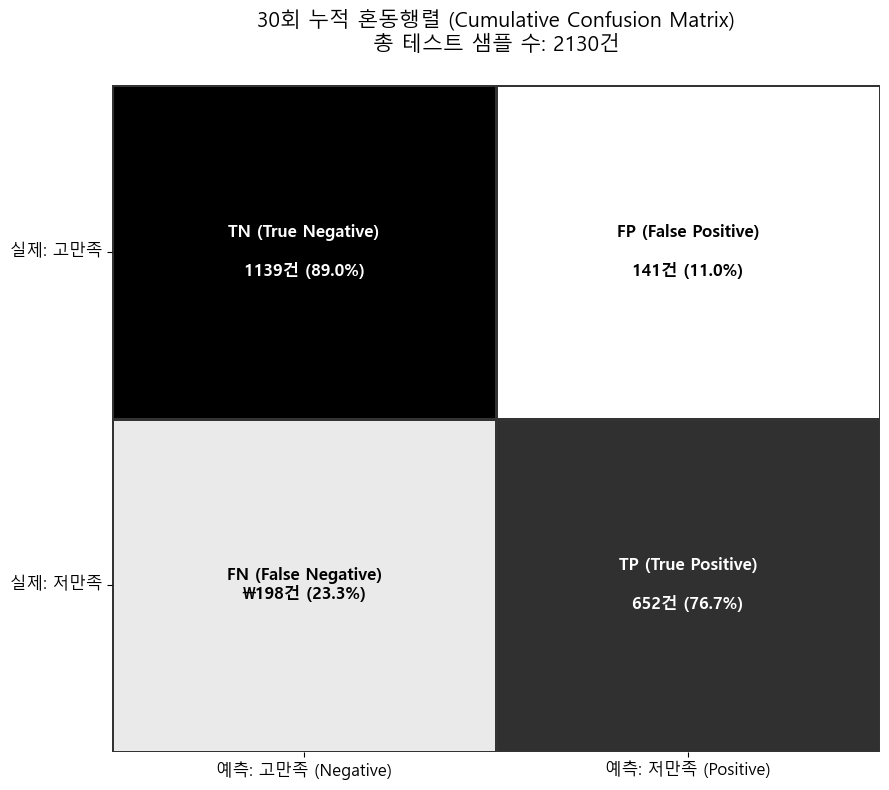

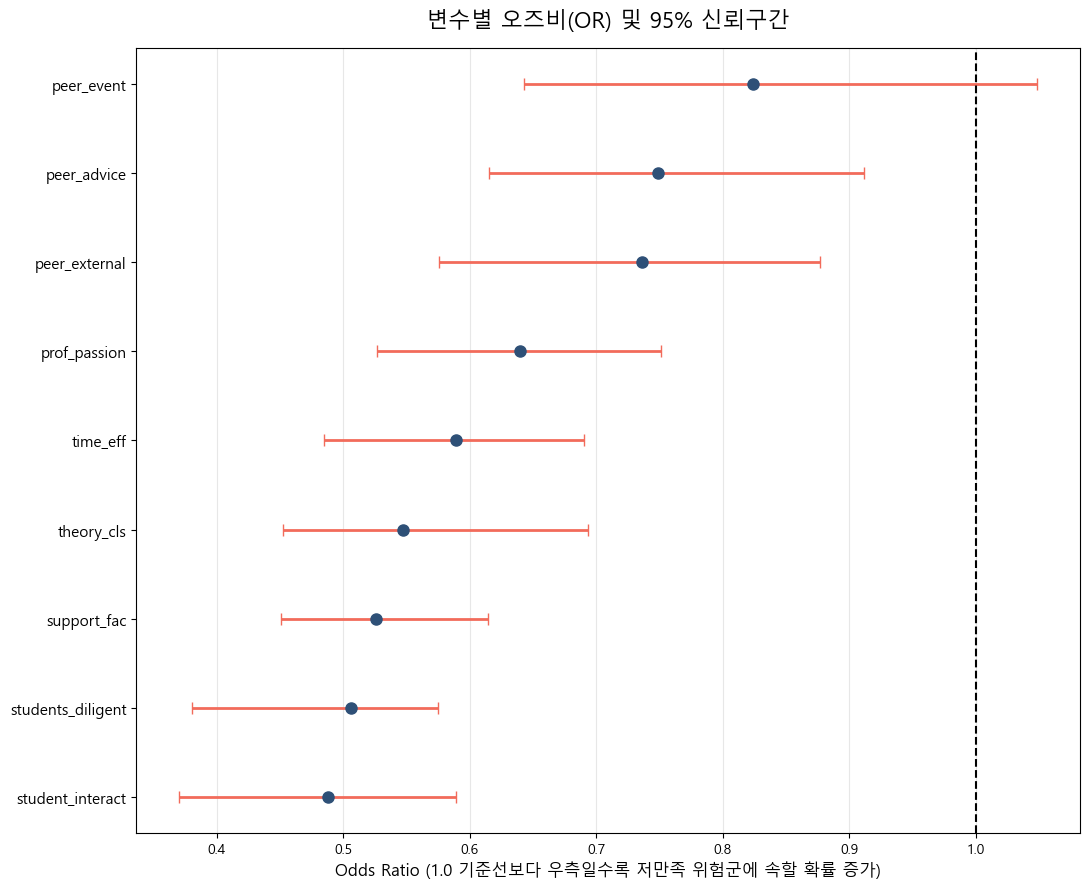

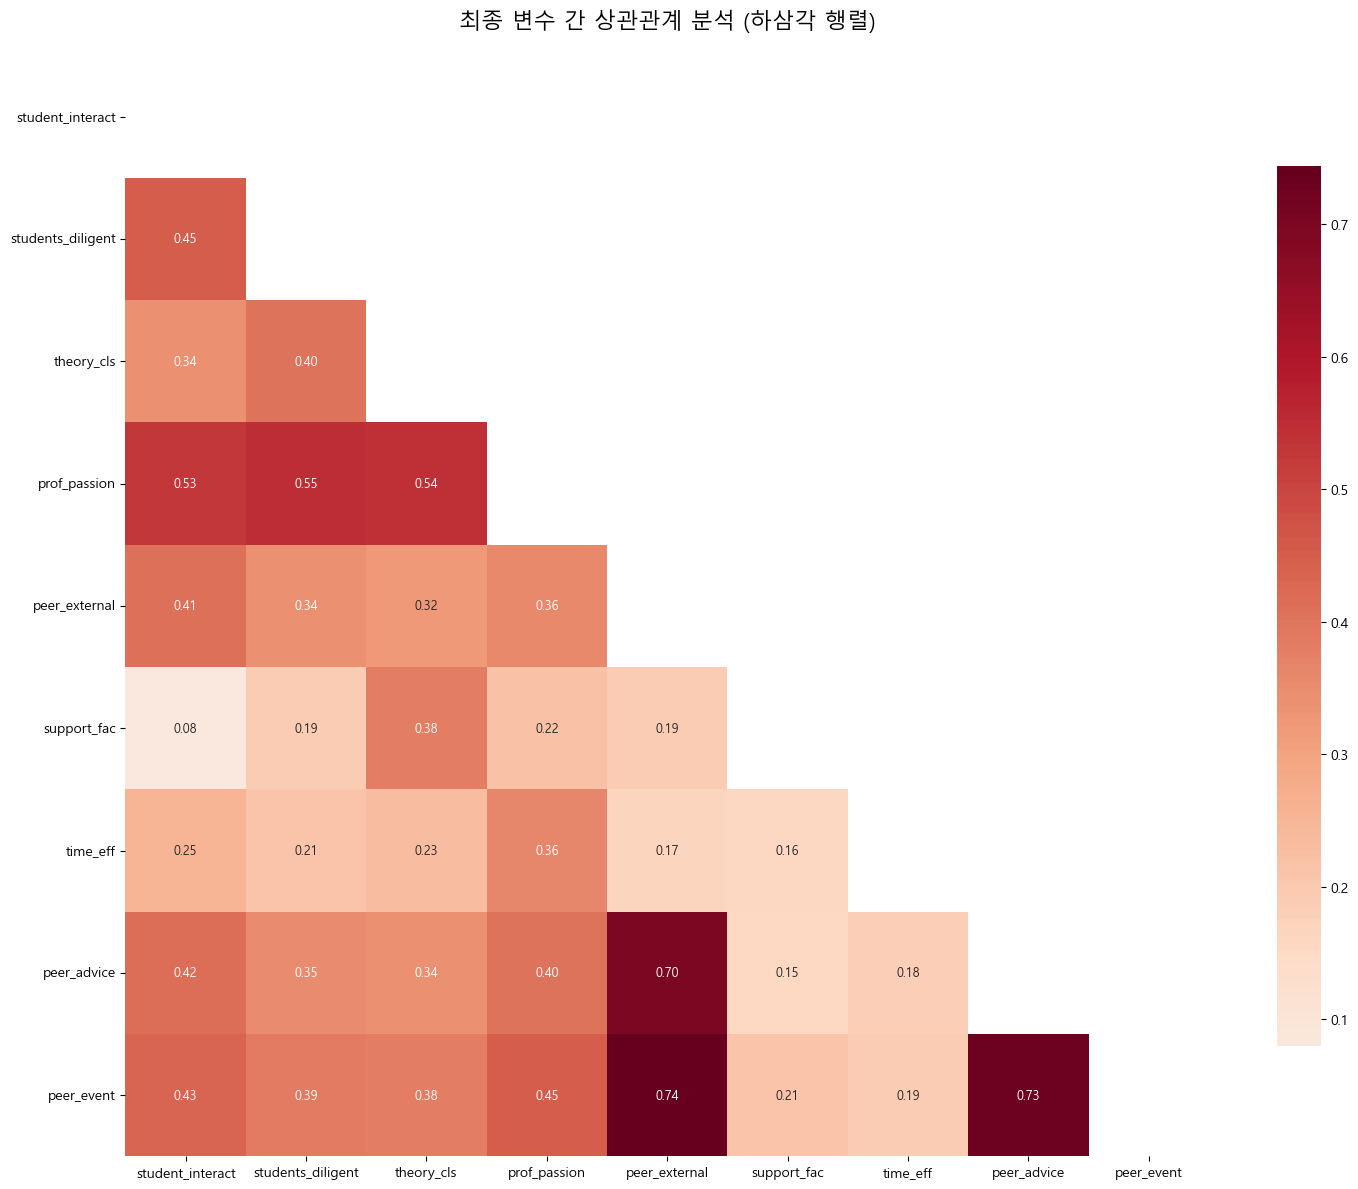

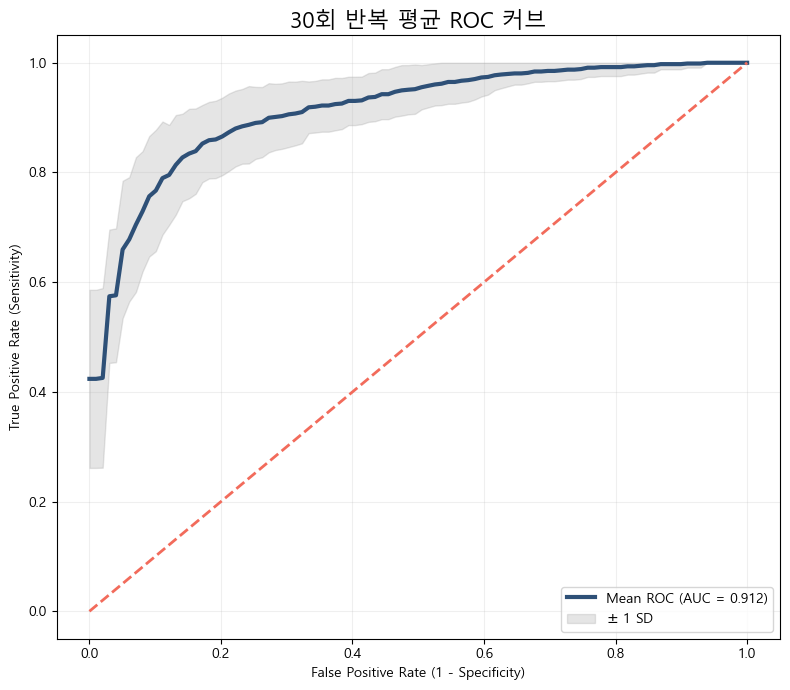

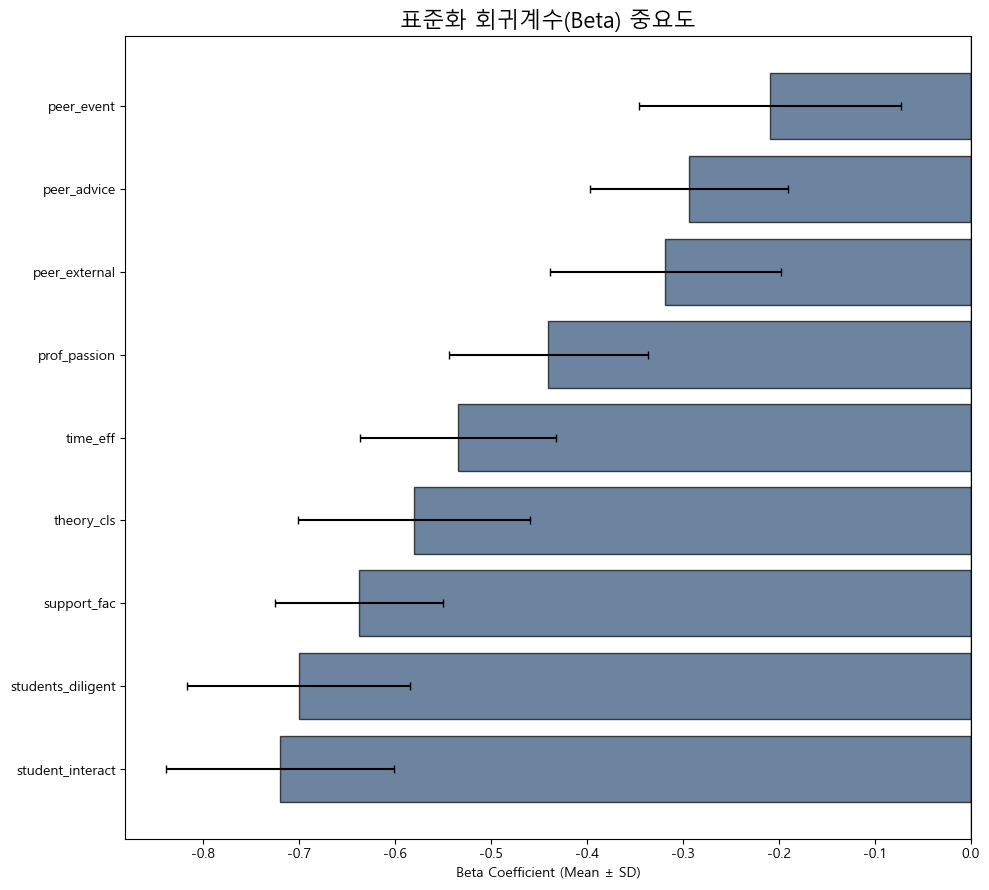


🚀 [최종 분석 결과 요약]


,특성,OR,Lower,Upper,VIF
0,peer_event,0.824,0.643,1.049,2.952
1,peer_advice,0.749,0.616,0.912,2.474
2,peer_external,0.737,0.576,0.877,2.577
3,prof_passion,0.639,0.527,0.751,2.102
4,time_eff,0.589,0.485,0.690,1.168
5,theory_cls,0.547,0.452,0.693,1.638
6,support_fac,0.526,0.451,0.614,1.203
7,students_diligent,0.506,0.381,0.575,1.565
8,student_interact,0.488,0.370,0.589,1.600



📊 [테스트 세트 평균 성능 지표]


,Recall_1(저만족),Recall_0(고만족),AUC,Accuracy
mean,0.767,0.889,0.912,0.828
std,0.061,0.053,0.036,0.039


In [13]:
# ======================================================================
# ✅ [최종 통합 분석] 개별 고해상도 시각화 + 95% CI + 누적 혼동행렬
# ======================================================================
# ======================================
# ✅ 최적모델(ElasticNet(K25)+LR) 8:2 분할 버전
# (1) Test 성능 30회 요약: 80% 학습 / 20% 테스트
# (2) 데이터 누수 방지: Train(80%)에서만 thr 산출 및 Scaler 학습
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score, 
                             roc_auc_score, roc_curve)
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 1) 데이터 준비 및 변수 설정
# -------------------------
vars_final = vars_enet_k25  # 이미 정의된 K=25 변수셋 사용
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# -------------------------
# 2) 반복 홀드아웃 실행 (8:2 분할)
# -------------------------
N_REP = 30
perf_rows = []
coef_mat = []
roc_list = []
cm_raw_list = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # ✅ [변경점] 8:2 분할 (train_val을 80%로 통합)
    X_train, X_test, sat_train, sat_test = train_test_split(
        X_full, sat_full, test_size=0.2, random_state=rs
    )

    # (1) thr = train(80%)의 median 산출 (누수 방지)
    thr = float(sat_train.median())

    # (2) 저만족=1, 고만족=0 라벨 생성
    y_train = (sat_train < thr).astype(int)
    y_test  = (sat_test  < thr).astype(int)

    # (3) 모델 구축 및 학습 (Pipeline 사용으로 Train 데이터로만 Scaling)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    
    fitted = model.fit(X_train[vars_final], y_train)

    # (4) Test 예측 및 성능 평가
    y_pred = fitted.predict(X_test[vars_final])
    y_score = fitted.predict_proba(X_test[vars_final])[:, 1]

    # 지표 계산
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (2 * precision_1 * recall_1 / (precision_1 + recall_1)) if (precision_1 + recall_1) > 0 else np.nan
    
    try:
        auc = roc_auc_score(y_test, y_score) if (len(np.unique(y_test)) == 2) else np.nan
    except:
        auc = np.nan

    perf_rows.append({
        "Recall_1": recall_1, "Precision_1": precision_1, "F1_1": f1_1, "ROC_AUC": auc
    })

    # 계수 및 ROC 데이터 저장
    coef_mat.append(fitted.named_steps["clf"].coef_.ravel())
    cm_raw_list.append(cm)
    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_list.append({"fpr": fpr, "tpr": tpr})

# -------------------------
# 3) 결과 요약 출력
# -------------------------
perf_df = pd.DataFrame(perf_rows)
print(f"\n✅ [8:2 분할] 30회 반복 성능 요약 (N_train={len(X_train)}, N_test={len(X_test)})")
display(perf_df.describe().loc[['mean', 'std', '50%']].rename(index={'50%': 'median'}))

# 변수 기여도(OR) 요약표 생성
coef_arr = np.vstack(coef_mat)
or_median = np.exp(np.median(coef_arr, axis=0))
coef_table = pd.DataFrame({
    "Feature": vars_final,
    "OR_median": or_median,
    "Beta_mean": coef_arr.mean(axis=0)
}).sort_values("OR_median", ascending=False)

print("\n✅ [변수 기여도 요약] OR > 1 이면 저만족 확률 증가")
display(coef_table.head(10))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score, roc_auc_score, roc_curve, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 0) 환경 설정 (색상 및 폰트)
# ---------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["axes.unicode_minus"] = False

# 한글 폰트 설정
for font_name in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if font_name in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font_name
        break

# 디자인 테마
MAIN_COLOR = "#2E5077"  # 네이비 (고만족/정상)
SUB_COLOR = "#F26B5B"   # 샐먼 (저만족/위험)

# ---------------------------------------------------------
# 1) 30회 반복 실행 및 데이터 수집
# ---------------------------------------------------------
vars_final = vars_enet_k25
X_full = df.drop(columns=["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"], errors='ignore').copy()
sat_full = df["sat"].copy()
X_final_data = X_full[vars_final].copy()

N_REP = 30
perf_rows, coef_list, tprs, cm_list = [], [], [], []
mean_fpr = np.linspace(0, 1, 100)

for rep in range(N_REP):
    rs = RANDOM_STATE + rep
    X_train_dev, X_test, sat_train_dev, sat_test = train_test_split(X_full, sat_full, test_size=0.2, random_state=rs)
    
    thr = float(sat_train_dev.median())
    y_train_dev = (sat_train_dev < thr).astype(int) # 저만족=1
    y_test = (sat_test < thr).astype(int)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    model.fit(X_train_dev[vars_final], y_train_dev)

    y_pred = model.predict(X_test[vars_final])
    y_score = model.predict_proba(X_test[vars_final])[:, 1]
    
    # 결과 저장
    perf_rows.append({
        "Recall_1(저만족)": confusion_matrix(y_test, y_pred)[1,1] / np.sum(y_test==1),
        "Recall_0(고만족)": confusion_matrix(y_test, y_pred)[0,0] / np.sum(y_test==0),
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": balanced_accuracy_score(y_test, y_pred)
    })
    cm_list.append(confusion_matrix(y_test, y_pred, labels=[0, 1]))
    coef_list.append(model.named_steps["clf"].coef_.ravel())
    
    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

# 통계 데이터 가공
coef_arr = np.array(coef_list)
or_arr = np.exp(coef_arr)
perf_df = pd.DataFrame(perf_rows)

# ======================================================================
# ✅ [최종 통합 분석] TN/FP/FN/TP 명시 혼동행렬 + 개별 고해상도 시각화
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, balanced_accuracy_score, roc_auc_score, roc_curve, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings

warnings.filterwarnings("ignore")

# 0) 환경 및 폰트 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if font_name in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font_name
        break

MAIN_COLOR = "#2E5077" 
SUB_COLOR = "#F26B5B"

# 1) 30회 반복 실행 및 데이터 수집 (기존 로직 동일)
vars_final = vars_enet_k25
X_full = df.drop(columns=["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"], errors='ignore').copy()
sat_full = df["sat"].copy()
X_final_data = X_full[vars_final].copy()

N_REP = 30
perf_rows, coef_list, tprs, cm_list = [], [], [], []
mean_fpr = np.linspace(0, 1, 100)

for rep in range(N_REP):
    rs = RANDOM_STATE + rep
    X_train_dev, X_test, sat_train_dev, sat_test = train_test_split(X_full, sat_full, test_size=0.2, random_state=rs)
    thr = float(sat_train_dev.median())
    y_train_dev = (sat_train_dev < thr).astype(int) 
    y_test = (sat_test < thr).astype(int)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    model.fit(X_train_dev[vars_final], y_train_dev)
    y_pred = model.predict(X_test[vars_final])
    y_score = model.predict_proba(X_test[vars_final])[:, 1]
    
    cm_list.append(confusion_matrix(y_test, y_pred, labels=[0, 1]))
    coef_list.append(model.named_steps["clf"].coef_.ravel())
    perf_rows.append({"AUC": roc_auc_score(y_test, y_score)})
    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        tprs.append(np.interp(mean_fpr, fpr, tpr))

coef_arr = np.array(coef_list)
or_arr = np.exp(coef_arr)

# ======================================================================
# 📊 [시각화 1] 30회 누적 혼동행렬 (TN, FP, FN, TP 표기)
# ======================================================================
cm_sum = np.sum(cm_list, axis=0)
cm_perc = cm_sum / cm_sum.sum(axis=1)[:, None] * 100

plt.figure(figsize=(9, 8))
# 배경 색상을 아주 연한 회색조로 설정하여 텍스트 강조
sns.heatmap(cm_perc, annot=False, cmap='Greys', cbar=False, linewidths=2, linecolor='#333333')

# 각 셀에 TN, FP, FN, TP 및 고만족/저만족 설명 추가
cell_labels = [
    [f"TN (True Negative)\n\n{cm_sum[0,0]}건 ({cm_perc[0,0]:.1f}%)", 
     f"FP (False Positive)\n\n{cm_sum[0,1]}건 ({cm_perc[0,1]:.1f}%)"],
    [f"FN (False Negative)\n\{cm_sum[1,0]}건 ({cm_perc[1,0]:.1f}%)", 
     f"TP (True Positive)\n\n{cm_sum[1,1]}건 ({cm_perc[1,1]:.1f}%)"]
]

for i in range(2):
    for j in range(2):
        # 비율에 따라 텍스트 색상 자동 조절 (가독성)
        text_color = "white" if cm_perc[i,j] > 60 else "black"
        # TP(저만족 탐지) 셀은 별도의 강조색(SUB_COLOR) 텍스트 고려 가능
        final_color = SUB_COLOR if (i==1 and j==1) and cm_perc[i,j] < 60 else text_color
        
        plt.text(j+0.5, i+0.5, cell_labels[i][j], ha='center', va='center', 
                 fontsize=12, fontweight='bold', color=final_color)

plt.xticks([0.5, 1.5], ["예측: 고만족 (Negative)", "예측: 저만족 (Positive)"], fontsize=12)
plt.yticks([0.5, 1.5], ["실제: 고만족", "실제: 저만족"], fontsize=12, rotation=0)
plt.title(f"30회 누적 혼동행렬 (Cumulative Confusion Matrix)\n총 테스트 샘플 수: {np.sum(cm_sum)}건", fontsize=15, pad=25)
plt.tight_layout()
plt.show()

# ======================================================================
# 📊 [시각화 2] 오즈비 Forest Plot
# ======================================================================
# (이전 코드와 동일 - 생략 없이 통합 실행 가능)
final_table = pd.DataFrame({
    "특성": vars_final,
    "OR": np.median(or_arr, axis=0),
    "Lower": np.quantile(or_arr, 0.025, axis=0),
    "Upper": np.quantile(or_arr, 0.975, axis=0)
}).sort_values("OR", ascending=False)

plt.figure(figsize=(11, 9))
y_pos = np.arange(len(final_table))
plt.errorbar(final_table["OR"], y_pos, 
             xerr=[final_table["OR"] - final_table["Lower"], final_table["Upper"] - final_table["OR"]],
             fmt='o', color=MAIN_COLOR, ecolor=SUB_COLOR, elinewidth=2, capsize=4, ms=8)
plt.axvline(1.0, color='black', linestyle='--', lw=1.5)
plt.yticks(y_pos, final_table["특성"], fontsize=11)
plt.title("변수별 오즈비(OR) 및 95% 신뢰구간", fontsize=16, pad=15)
plt.xlabel("Odds Ratio (1.0 기준선보다 우측일수록 저만족 위험군에 속할 확률 증가)", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# [중요] 나머지 시각화(상관계수, ROC, Beta)도 동일한 방식으로 개별 plt.show() 하시면 됩니다.


# ======================================================================
# 📊 [시각화 3] 특성 간 상관행렬 (Heatmap)
# ======================================================================
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(X_final_data.corr(), dtype=bool))
sns.heatmap(X_final_data.corr(), mask=mask, annot=True, fmt=".2f", 
            cmap='RdBu_r', center=0, annot_kws={"size": 9}, cbar_kws={"shrink": .8})
plt.title("최종 변수 간 상관관계 분석 (하삼각 행렬)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ======================================================================
# 📊 [시각화 4] 평균 ROC 커브
# ======================================================================
plt.figure(figsize=(8, 7))
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
plt.plot(mean_fpr, mean_tpr, color=MAIN_COLOR, lw=3, 
         label=f'Mean ROC (AUC = {perf_df["AUC"].mean():.3f})')
std_tpr = np.std(tprs, axis=0)
plt.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr, 0), np.minimum(mean_tpr+std_tpr, 1), 
                 color='grey', alpha=0.2, label='$\pm$ 1 SD')
plt.plot([0, 1], [0, 1], color=SUB_COLOR, linestyle='--', lw=2)
plt.title("30회 반복 평균 ROC 커브", fontsize=16)
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ======================================================================
# 📊 [시각화 5] 회귀계수 중요도 (Beta)
# ======================================================================
beta_summary = pd.DataFrame({
    "특성": vars_final,
    "Beta": np.mean(coef_arr, axis=0),
    "SD": np.std(coef_arr, axis=0)
}).sort_values("Beta")

plt.figure(figsize=(10, 9))
plt.barh(beta_summary["특성"], beta_summary["Beta"], xerr=beta_summary["SD"], 
         color=MAIN_COLOR, alpha=0.7, edgecolor='black', capsize=3)
plt.axvline(0, color='black', lw=1)
plt.title("표준화 회귀계수(Beta) 중요도", fontsize=16)
plt.xlabel("Beta Coefficient (Mean ± SD)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2) 최종 수치 요약 보고
# ---------------------------------------------------------
print("\n" + "="*60)
print("🚀 [최종 분석 결과 요약]")
print("="*60)
X_vif = add_constant(X_final_data)
vif_df = pd.DataFrame({"특성": X_vif.columns, "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]}).query("특성 != 'const'")
final_report = pd.merge(final_table, vif_df, on="특성").sort_values("OR", ascending=False)
display(final_report.round(3))

print("\n📊 [테스트 세트 평균 성능 지표]")
display(perf_df.describe().loc[['mean', 'std']].round(3))